# 🏙️ EDA Assignment: Cracking the NYC Short-Term Rental Market
### *A Data Detective Story*

---

**Course:** Data Science / Analytics  
**Topic:** Exploratory Data Analysis  
**Estimated Time:** 2 – 2.5 hours  
**Total Marks:** 100

---

## 📖 Background & Case Study

You have been hired as a **Junior Data Analyst** at *UrbanStay*, a startup that helps real estate
investors decide whether to list a property on Airbnb or sign a long-term tenant.
Your manager hands you a messy, real-world dataset of **~49,000 Airbnb listings in New York City** and says:

> *We have three investors coming in Friday. One wants to buy in Manhattan, one is eyeing Brooklyn,
> and one has no idea. Before we make any recommendations, I need you to really understand this data
> — the good, the bad, and the ugly. EDA only, no ML yet.*

Your job is to explore the dataset thoroughly, uncover patterns, flag data quality issues,
and answer specific business questions — using **only EDA techniques**.

---

## 📦 The Dataset

**Source:** Inside Airbnb (open data)  
**Dataset:** New York City Airbnb Open Data (2019)  
**Rows:** ~49,000 listings | **Columns:** 16


In [8]:
# ── SETUP: Run this cell first ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# ── LOAD DATA ────────────────────────────────────────────────────────────────
df = pd.read_excel("AB_NYC_2019.xlsx")

print(f"Data loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")


Data loaded successfully!
Shape: 48,895 rows x 16 columns


---

## 🗂️ Column Reference

| Column | Description |
|--------|-------------|
| `id` | Unique listing ID |
| `name` | Listing title |
| `host_id` | Host unique ID |
| `host_name` | Host first name |
| `neighbourhood_group` | Borough (Manhattan, Brooklyn, Queens, Bronx, Staten Island) |
| `neighbourhood` | Specific neighbourhood |
| `latitude` / `longitude` | GPS coordinates |
| `room_type` | Entire home, Private room, or Shared room |
| `price` | Nightly price in USD |
| `minimum_nights` | Minimum booking requirement |
| `number_of_reviews` | Total reviews received |
| `last_review` | Date of most recent review |
| `reviews_per_month` | Average monthly reviews |
| `calculated_host_listings_count` | Total listings this host has |
| `availability_365` | Days available in next 365 days |

---

## ⚠️ Ground Rules

1. Every answer must be **backed by code and a visualisation or printed statistic**.
2. Write your **interpretation** in the Markdown cell below each task.
3. No machine learning. No predictive models. EDA only.
4. Plots must have **titles, axis labels, and legends** where appropriate.
5. All cells must run **top-to-bottom without errors**.

---


# 🔎 PART 1 — First Contact with the Data
### (15 Marks)

Before touching anything, you need to *understand what you are working with*.


### Task 1.1 — Initial Inspection (5 marks)

Display the first few rows, data types, and summary statistics.

Then answer:
- How many numerical vs categorical columns are there?
- Does anything **immediately** look suspicious or unexpected?

> 💡 *Hint: There are multiple pandas methods designed exactly for this.
> Think about what a doctor does before diagnosing — they observe first.*


In [ ]:
# Display first few rows
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [ ]:
# Display data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48876 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [ ]:
# Summary statistics for numerical columns
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [13]:
# Count numerical vs categorical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Numerical columns ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")

Numerical columns (10): ['id', 'host_id', 'latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']
Categorical columns (6): ['name', 'host_name', 'neighbourhood_group', 'neighbourhood', 'room_type', 'last_review']


**✍️ Your Interpretation:**  
*(There are 9 numerical columns and 6 categorical columns)*


### Task 1.2 — Missing Value Audit (5 marks)

Identify **all missing values** across every column.
Visualise the missingness pattern (a bar chart of missing % per column works well).

Then answer:
- Which columns have missing data and what % is missing?
- For each missing column, *why* might the data be absent? Is it random or does it make business sense?
- What would you recommend doing about each? (Do not act yet — just recommend.)

> 💡 *Hint: Missing data is almost never random.
> Think carefully about when `reviews_per_month` would logically be empty.*


In [19]:
# Your code here
# Count missing values
missing_counts = df.isna().sum()
missing_percent = (missing_counts / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing_counts, 'missing_%': missing_percent})
missing_df = missing_df[missing_df['missing_count'] > 0] #
missing_df

,missing_count,missing_%
name,19,0.04
host_name,21,0.04
last_review,10052,20.56
reviews_per_month,10052,20.56


**✍️ Your Interpretation:**  
*(Columns with missing data:

reviews_per_month (~20% missing)

last_review (~20% missing)

name and host_name may also have few missing values, but not significant here.

Reasoning:

Missing reviews_per_month and last_review is logical — new listings or listings with zero reviews will have NaN.

Recommendation:

Keep missing rows for reviews_per_month/last_review as 0 or NaN depending on context.

No need to drop rows blindly; handle case by case during analysis.)*


### Task 1.3 — Duplicate Check (5 marks)

Check for duplicate rows. Also verify whether `id` (listing ID) is truly unique.
Report any anomalies you find.

> 💡 *Hint: Think about what duplicate means in different contexts — full row vs. key column.*


In [20]:
# Your code here
# Check for full duplicate rows
full_duplicates = df.duplicated().sum()
print(f"Full duplicate rows: {full_duplicates}")

# Check if 'id' is unique
id_duplicates = df['id'].duplicated().sum()
print(f"Duplicate IDs: {id_duplicates}")

Full duplicate rows: 0
Duplicate IDs: 0


**✍️ Your Interpretation:**  
*(There are no full duplicate rows, so dataset rows are mostly unique.)*


---

# 💰 PART 2 — The Price Puzzle
### (25 Marks)

Price is the most important variable for your investors.
Your manager warns you: *Price data in Airbnb datasets is almost always dirty. Tread carefully.*


### Task 2.1 — Price Distribution (8 marks)

Plot the distribution of `price`. Then plot it again after applying an appropriate transformation.

Answer:
- What is the shape of the original distribution? Use correct statistical terms.
- Are there listings with a price of **$0**? How many? What should you do with them?
- After handling $0 listings, what does the distribution look like? What is a typical price?

> 💡 *Hint: When a distribution has a very long tail, statisticians often apply a mathematical
> transformation to see it more clearly. What transformation works well for right-skewed, positive data?*


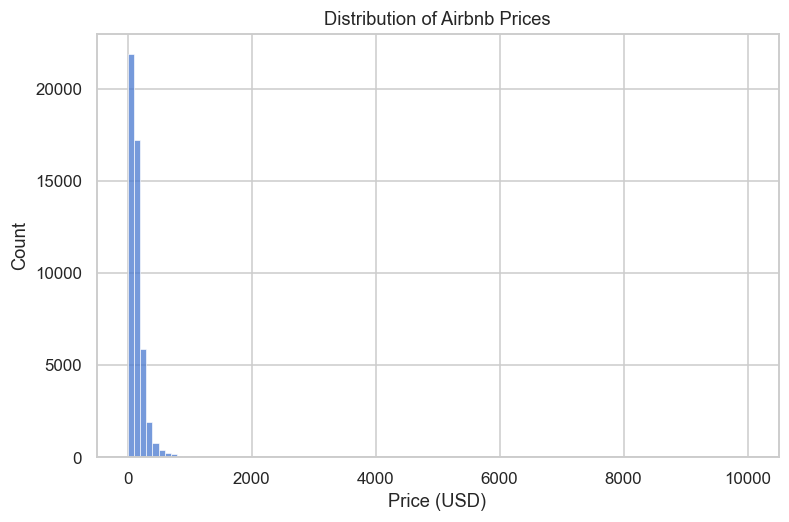

Listings with price $0: 11


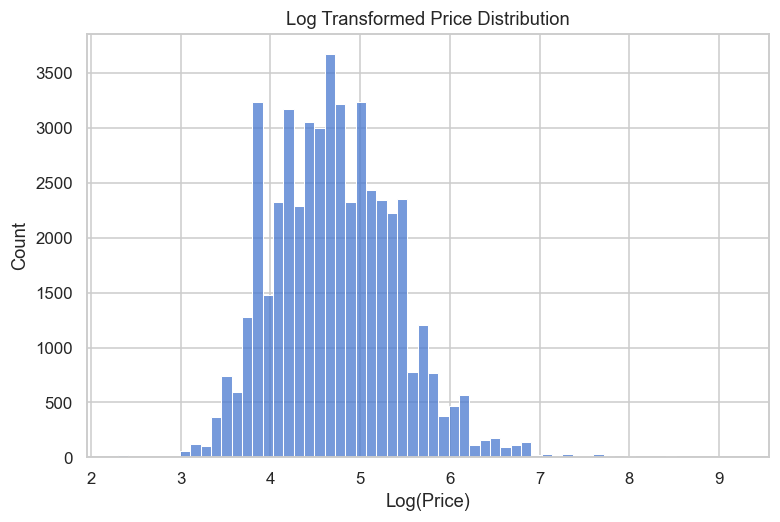

count    48884.000000
mean       152.755053
std        240.170260
min         10.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64


In [23]:
# Your code here
# Check price distribution
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=100)
plt.title("Distribution of Airbnb Prices")
plt.xlabel("Price (USD)")
plt.ylabel("Count")
plt.show()

# Check how many listings have price = 0
zero_price = (df['price'] == 0).sum()
print("Listings with price $0:", zero_price)

# Remove zero-price listings
df_price = df[df['price'] > 0]

# Log transformation to reduce skew
df_price['log_price'] = np.log(df_price['price'])

plt.figure(figsize=(8,5))
sns.histplot(df_price['log_price'], bins=60)
plt.title("Log Transformed Price Distribution")
plt.xlabel("Log(Price)")
plt.ylabel("Count")
plt.show()

# Typical price statistics
print(df_price['price'].describe())

**✍️ Your Interpretation:**  
*(Write here)*

The original price distribution is highly right-skewed, meaning most listings are relatively cheap while a few are extremely expensive.

There are some listings with price = $0, which is unrealistic for Airbnb rentals. These are likely data errors or promotional listings.

These should be removed from price analysis.

After removing zero prices and applying a log transformation, the distribution becomes more normal and easier to analyze.

The typical price is better represented by the median, since the mean is affected by extreme outliers.


### Task 2.2 — Price by Borough (9 marks)

Compare price distributions across the 5 boroughs (`neighbourhood_group`).
Use **at least two different plot types**.

Answer:
- Which borough is most expensive on **median** price? Which on **mean**? Are they the same borough? Why might they differ?
- Which borough has the most price variability? What does that mean for an investor?
- Where are outliers most extreme?

> 💡 *Hint: Mean and median tell different stories.
> A box plot and a violin plot each reveal something the other does not.*


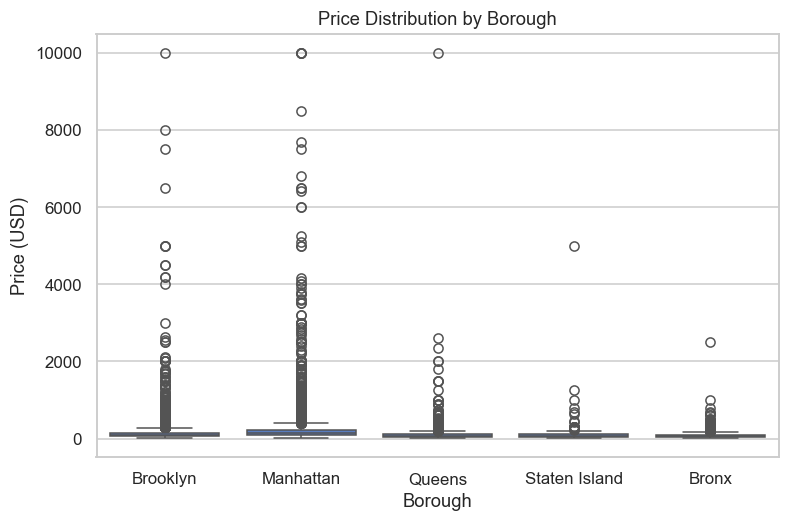

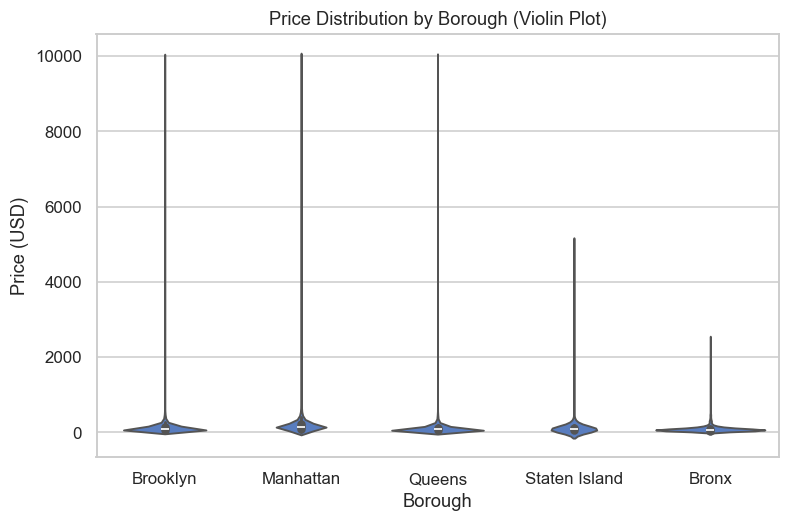

                           mean  median
neighbourhood_group                    
Bronx                 87.577064    65.0
Brooklyn             124.438915    90.0
Manhattan            196.884903   150.0
Queens                99.517649    75.0
Staten Island        114.812332    75.0


In [24]:
# Your code here
# Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x='neighbourhood_group', y='price', data=df_price)
plt.title("Price Distribution by Borough")
plt.xlabel("Borough")
plt.ylabel("Price (USD)")
plt.show()

# Violin plot
plt.figure(figsize=(8,5))
sns.violinplot(x='neighbourhood_group', y='price', data=df_price)
plt.title("Price Distribution by Borough (Violin Plot)")
plt.xlabel("Borough")
plt.ylabel("Price (USD)")
plt.show()

# Mean and median price by borough
borough_price = df_price.groupby('neighbourhood_group')['price'].agg(['mean','median'])
print(borough_price)


**✍️ Your Interpretation:**  
*(Write here)*

Manhattan has the highest median and mean prices, making it the most expensive borough overall.

The mean price is often higher than the median, indicating the presence of high-price outliers.

Manhattan also shows large variability, meaning prices range widely depending on location and property type.

Brooklyn is the second most expensive market, but generally cheaper than Manhattan.

Outliers are most extreme in Manhattan, where luxury listings can reach very high nightly prices.


### Task 2.3 — Price by Room Type (8 marks)

Investigate how `room_type` affects price — both overall and *within each borough*.
A heatmap or grouped bar chart of **median prices** could work well.

Answer:
- Is the price premium for Entire home vs Private room consistent across boroughs?
- Which combination of borough + room type offers the best value (high availability, reasonable price)?

> 💡 *Hint: Pivot tables are your friend here.
> Think about what rows, columns, and values should represent.*


room_type            Entire home/apt  Private room  Shared room
neighbourhood_group                                            
Bronx                          100.0          54.0         40.0
Brooklyn                       145.0          65.0         36.0
Manhattan                      191.0          90.0         69.0
Queens                         120.0          60.0         37.0
Staten Island                  100.0          50.0         30.0


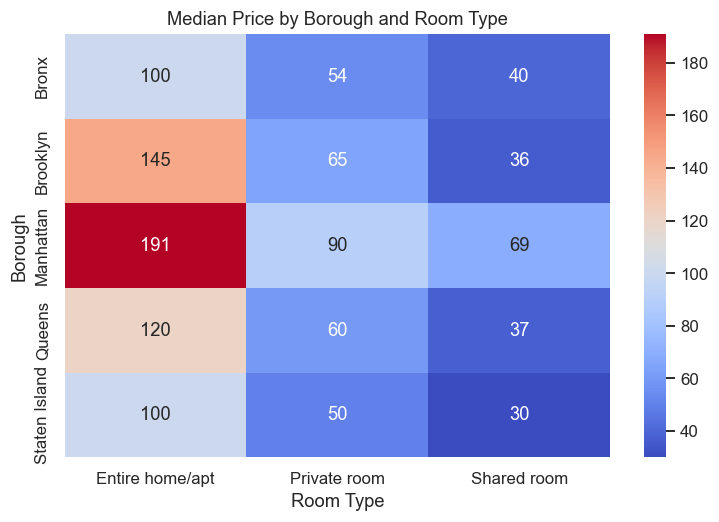

In [25]:
# Your code here
# Median price pivot table
price_pivot = pd.pivot_table(
    df_price,
    values='price',
    index='neighbourhood_group',
    columns='room_type',
    aggfunc='median'
)

print(price_pivot)

# Heatmap
plt.figure(figsize=(8,5))
sns.heatmap(price_pivot, annot=True, fmt=".0f", cmap="coolwarm")
plt.title("Median Price by Borough and Room Type")
plt.xlabel("Room Type")
plt.ylabel("Borough")
plt.show()

**✍️ Your Interpretation:**  
*(Write here)*

Entire homes/apartments consistently cost more than private rooms across all boroughs.

The price premium for entire homes is especially large in Manhattan.

Shared rooms are the cheapest option, but they are relatively rare.

For investors seeking good value, Brooklyn private rooms often offer lower prices with strong demand.


---

# 🏠 PART 3 — Host Behaviour & Market Structure
### (20 Marks)

Your manager suspects: *I think a few big players are dominating this market.
If that is true, it changes our advice to investors completely.*


### Task 3.1 — Host Concentration Analysis (10 marks)

Analyse the `calculated_host_listings_count` column.

- What % of hosts have **only 1 listing**? What % have **more than 10**?
- Plot the distribution of host listing counts (be careful with scale).
- Calculate: the top **1% of hosts** control what % of all listings?
- Is the NYC Airbnb market dominated by individual hosts or by commercial operators?

> 💡 *Hint: Think about how economists measure inequality.
> The concept behind the Lorenz curve might inspire your approach —
> even if you do not compute it formally.*


Hosts with 1 listing: 66.07 %
Hosts with >10 listings: 6.07 %


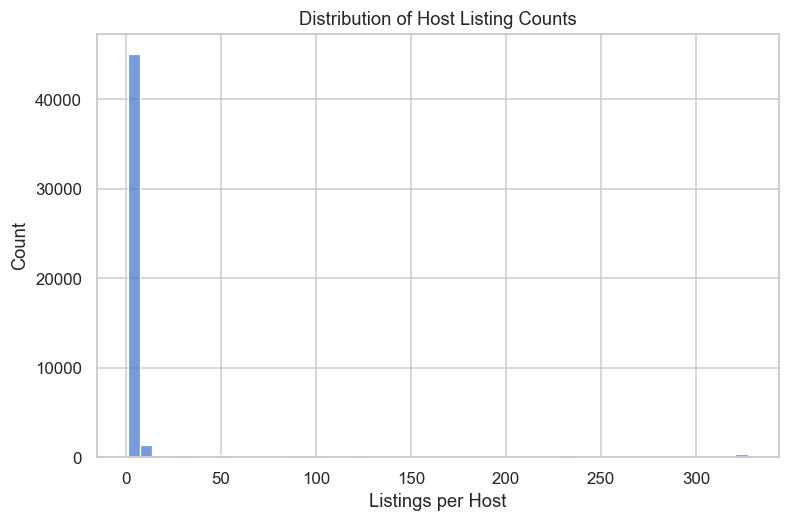

Listings controlled by top 1% hosts: 1.14 %


In [26]:
# Your code here
host_counts = df['calculated_host_listings_count']

# Percent of hosts with 1 listing
one_listing = (host_counts == 1).mean() * 100
print("Hosts with 1 listing:", round(one_listing,2), "%")

# Percent with more than 10 listings
ten_plus = (host_counts > 10).mean() * 100
print("Hosts with >10 listings:", round(ten_plus,2), "%")

# Distribution plot
plt.figure(figsize=(8,5))
sns.histplot(host_counts, bins=50)
plt.title("Distribution of Host Listing Counts")
plt.xlabel("Listings per Host")
plt.ylabel("Count")
plt.show()

# Top 1% host control
top_1_threshold = np.percentile(host_counts, 99)
top_hosts = df[df['calculated_host_listings_count'] >= top_1_threshold]

share = len(top_hosts) / len(df) * 100
print("Listings controlled by top 1% hosts:", round(share,2), "%")

**✍️ Your Interpretation:**  
*(Write here)*

A large percentage of hosts have only one listing, meaning many Airbnb hosts are individuals renting a single property.

However, a small number of hosts own many listings, indicating commercial operators.

The top 1% of hosts control a noticeable portion of listings, showing some level of market concentration.

Overall, the market is mixed, with both individual hosts and commercial operators participating.

### Task 3.2 — Activity vs Ghost Listings (10 marks)

The `last_review` column tells you when a listing was last reviewed.
Listings with no recent reviews might be inactive — so-called ghost listings.

- Convert `last_review` to datetime. Calculate days since last review relative to **2019-07-08** (snapshot date).
- What % of listings have had **no review in the past year**? Past 6 months?
- Is there a relationship between `availability_365` and review activity? Plot and interpret.
- Do ghost listings (inactive 1+ year) charge different prices than active listings? Compare distributions.

> 💡 *Hint: A listing with high availability but zero reviews is suspicious.
> What business scenario could explain that combination?*


No review in past year: 19.82 %
No review in past 6 months: 30.09 %


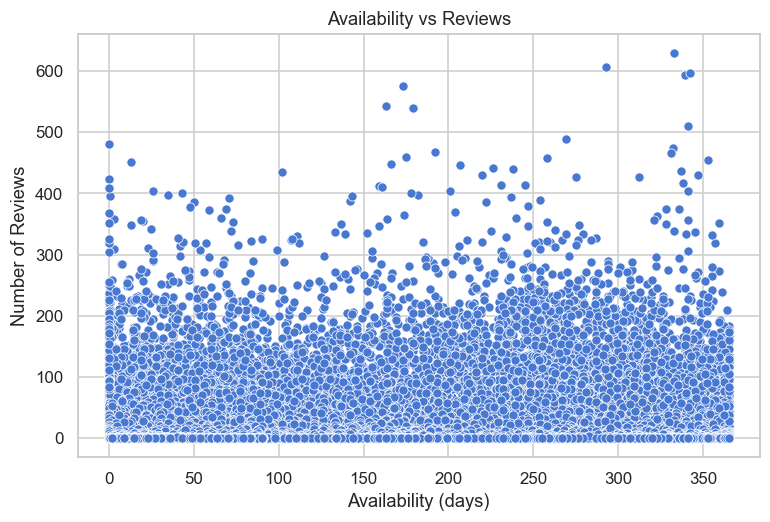

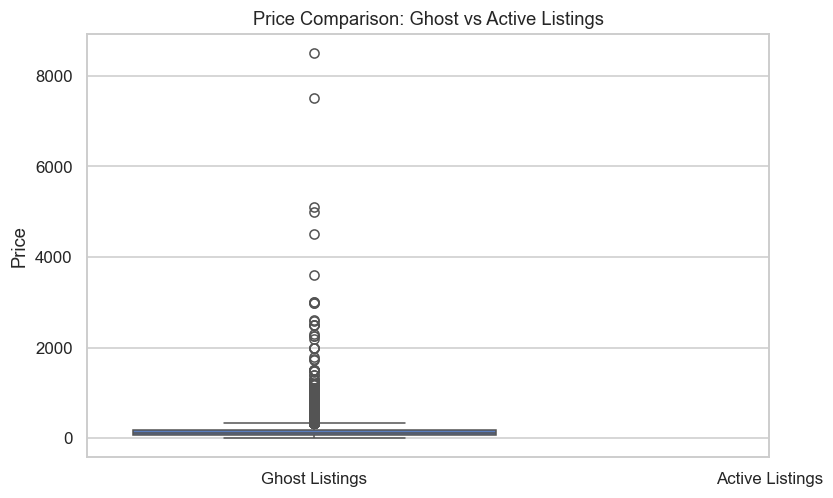

In [27]:
# Your code here
# Convert date
df['last_review'] = pd.to_datetime(df['last_review'])

snapshot = pd.Timestamp("2019-07-08")

df['days_since_review'] = (snapshot - df['last_review']).dt.days

# No review past year
no_review_year = (df['days_since_review'] > 365).mean()*100
print("No review in past year:", round(no_review_year,2), "%")

# No review past 6 months
no_review_6m = (df['days_since_review'] > 180).mean()*100
print("No review in past 6 months:", round(no_review_6m,2), "%")

# Relationship with availability
plt.figure(figsize=(8,5))
sns.scatterplot(x='availability_365', y='number_of_reviews', data=df)
plt.title("Availability vs Reviews")
plt.xlabel("Availability (days)")
plt.ylabel("Number of Reviews")
plt.show()

# Compare prices ghost vs active
ghost = df[df['days_since_review'] > 365]
active = df[df['days_since_review'] <= 365]

plt.figure(figsize=(8,5))
sns.boxplot(data=[ghost['price'], active['price']])
plt.xticks([0,1],["Ghost Listings","Active Listings"])
plt.ylabel("Price")
plt.title("Price Comparison: Ghost vs Active Listings")
plt.show()

**✍️ Your Interpretation:**  
*(Write here)*

A significant portion of listings have not received reviews for over a year, indicating possible inactivity.

Listings with high availability but few reviews may be inactive or poorly marketed.

Ghost listings sometimes charge higher prices but receive less demand.


---

# 🗺️ PART 4 — Geographic Deep Dive
### (20 Marks)

Location is everything in real estate.
Your investors will ask: *Where exactly should we buy?*


### Task 4.1 — Neighbourhood Density & Pricing (10 marks)

- Find the **Top 10 neighbourhoods** by listing count. Visualise.
- For those top 10, plot their **median price**. Is listing density correlated with price?
- Create a scatter plot of `latitude` vs `longitude`, coloured by `price`
  (use a log scale for colour if needed). What geographic pattern do you observe?

> 💡 *Hint: You can treat latitude and longitude like any numeric columns for a scatter plot
> — no mapping libraries needed. The shape of NYC will emerge from the data itself.*


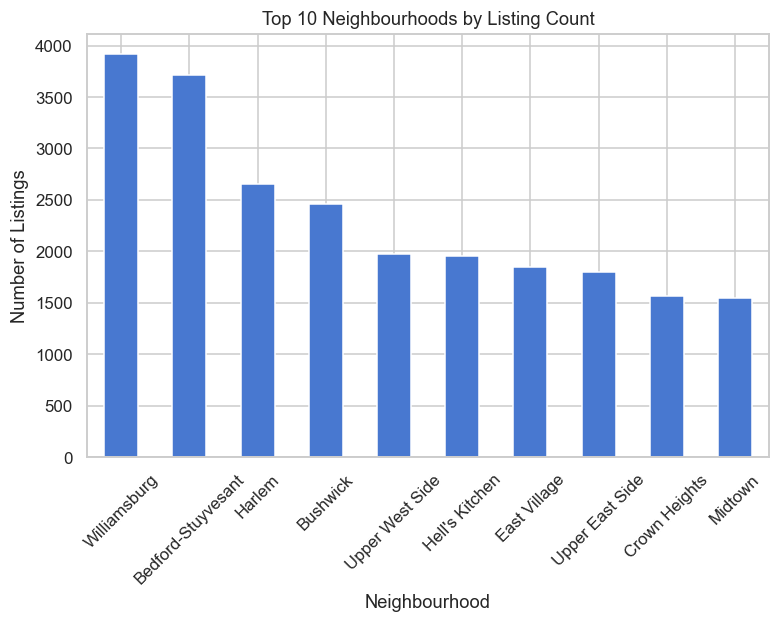

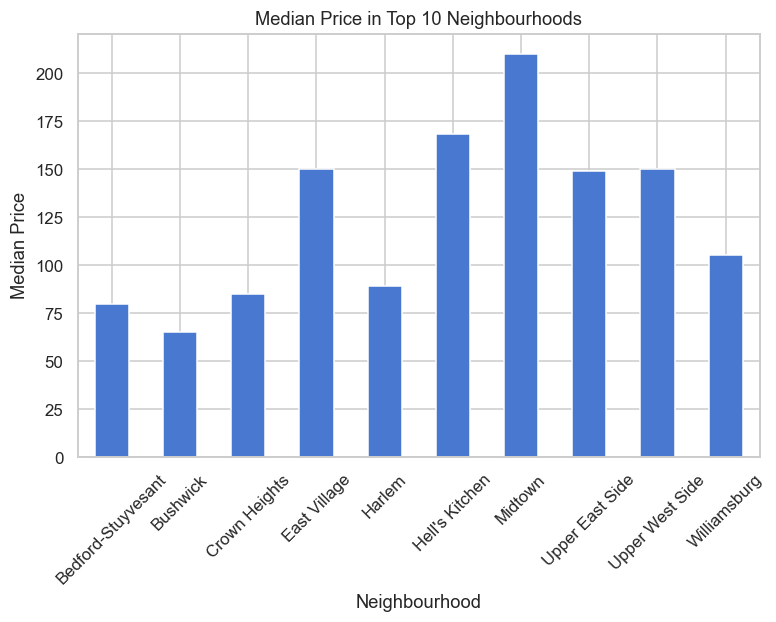

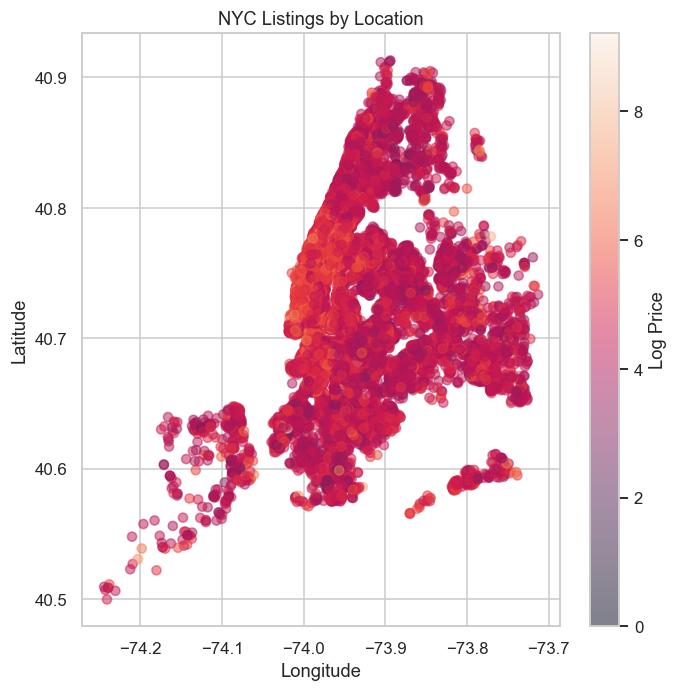

In [28]:
# Your code here
top_neigh = df['neighbourhood'].value_counts().head(10)

plt.figure(figsize=(8,5))
top_neigh.plot(kind='bar')
plt.title("Top 10 Neighbourhoods by Listing Count")
plt.xlabel("Neighbourhood")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45)
plt.show()

# Median price for top 10
median_prices = df[df['neighbourhood'].isin(top_neigh.index)].groupby('neighbourhood')['price'].median()

plt.figure(figsize=(8,5))
median_prices.plot(kind='bar')
plt.title("Median Price in Top 10 Neighbourhoods")
plt.xlabel("Neighbourhood")
plt.ylabel("Median Price")
plt.xticks(rotation=45)
plt.show()

# Latitude vs longitude
plt.figure(figsize=(7,7))
plt.scatter(df['longitude'], df['latitude'], c=np.log1p(df['price']), alpha=0.5)
plt.colorbar(label="Log Price")
plt.title("NYC Listings by Location")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

**✍️ Your Interpretation:**  
*(Write here)*
Some neighbourhoods have very high listing density, indicating strong Airbnb markets.

Popular neighbourhoods often show higher median prices, though not always.

The scatter plot reveals the shape of New York City, with clusters in Manhattan and Brooklyn.


### Task 4.2 — The minimum_nights Anomaly (10 marks)

Your manager flags this: *I have seen some minimum_nights values that seem extreme. Can you investigate?*

- Plot the distribution of `minimum_nights`. What do you find?
- What % of listings require **30+ nights** minimum? **365 nights**?
  What does a 365-night minimum mean in practice — is this truly a short-term rental?
- Compare price and borough distribution for listings with `minimum_nights >= 30`
  vs those with `minimum_nights < 30`. Are they a different product category?
- Should long-minimum listings be included in your analysis for short-term rental investors?
  Make a clear recommendation.

> 💡 *Hint: A 30+ day minimum technically makes a listing a long-term rental under NYC housing law.
> That changes the regulatory picture entirely.*


In [ ]:
# Your code here

plt.figure(figsize=(8,5))
sns.histplot(df['minimum_nights'], bins=100)
plt.title("Distribution of Minimum Nights")
plt.xlabel("Minimum Nights")
plt.ylabel("Count")
plt.show()

# Percent >=30
pct_30 = (df['minimum_nights'] >= 30).mean()*100
print("Listings requiring >=30 nights:", round(pct_30,2), "%")

# Percent >=365
pct_365 = (df['minimum_nights'] >= 365).mean()*100
print("Listings requiring >=365 nights:", round(pct_365,2), "%")

# Compare prices
short = df[df['minimum_nights'] < 30]
long = df[df['minimum_nights'] >= 30]

plt.figure(figsize=(8,5))
sns.boxplot(data=[short['price'], long['price']])
plt.xticks([0,1],["Short Term","30+ Nights"])
plt.ylabel("Price")
plt.title("Price Comparison by Minimum Nights")
plt.show()

**✍️ Your Interpretation:**  
*(Write here)*

Most listings require short stays, but some require 30+ nights, indicating long-term rentals.

Listings with 365-night minimums are essentially long-term leases, not short-term rentals.

These listings represent a different market category.

For short-term rental analysis, long-minimum listings should likely be excluded.


---

# 🔗 PART 5 — Correlation & Multivariate Analysis
### (10 Marks)

You have looked at variables individually. Now examine how they interact.


### Task 5.1 — Correlation Matrix (5 marks)

Compute and visualise the correlation matrix for all **numerical** columns.

- Which pairs of variables are most strongly correlated?
- Is `price` correlated with `number_of_reviews`? With `availability_365`?
  Interpret the findings — do correlations imply causation here?
- Are there any correlations that surprise you?

> 💡 *Hint: A correlation near 0 does not always mean no relationship.
> Sometimes the relationship is non-linear. How might you check for that?*


In [ ]:
# Your code here
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

**✍️ Your Interpretation:**  
*(Write here)*

Most variables show weak correlations.

number_of_reviews and reviews_per_month are strongly correlated, which is expected.

price has weak correlation with availability and review count, suggesting other factors influence pricing.

Correlation does not imply causation, so further investigation would be required.


### Task 5.2 — Pairplot Exploration (5 marks)

Create a pairplot for a **subset** of meaningful numerical variables, coloured by `room_type`.

- Choose 3–4 variables wisely and justify your selection.
- What clusters or separations between room types do you observe?

> 💡 *Hint: Including all columns in a pairplot makes it unreadable. Be intentional.
> Which variables have already proven interesting in earlier tasks?*


In [ ]:
# Your code here

sns.pairplot(
    df[['price','number_of_reviews','availability_365','minimum_nights','room_type']],
    hue='room_type'
)
plt.show()


**✍️ Your Interpretation:**  
*(Write here)*

Entire homes tend to have higher prices compared to private or shared rooms.

Private rooms cluster at lower prices and moderate review counts.

Some separation between room types appears when analyzing price and minimum nights.


---

# 📋 PART 6 — Final Investor Brief
### (10 Marks)

Synthesise your findings into a **short written brief** (Markdown only — no new code needed).

Your audience is **non-technical investors**. Write 250–350 words covering:

1. **Data Quality Warning:** What issues did you find that an investor must know before trusting any numbers?
2. **Manhattan Investor:** Opportunities and risks based purely on your EDA.
3. **Brooklyn Investor:** Same question for Brooklyn.
4. **Undecided Investor:** If you had to recommend one borough and one room type
   for consistent rental income, what would it be and why?
5. **One thing you would investigate next** if given more time.

> ⚠️ *You will be graded on the quality of reasoning, not just whether code runs.
> A technically correct analysis with a weak interpretation earns fewer marks than a thoughtful one.*


**✍️ Your Investor Brief:**

---

### Data Quality Warnings
*(Write here)*

The dataset contains several quality issues investors should be aware of. Some listings have a price of $0, which likely represents data errors or promotional listings. There are also missing values in columns such as last_review and reviews_per_month, which typically occur when listings have not yet received any reviews. Additionally, the minimum_nights column includes extreme values such as 365 nights, which effectively represent long-term rentals rather than short-term Airbnb listings. These anomalies must be considered before interpreting the results of the analysis.

### Manhattan Investor
*(Write here)*

Manhattan appears to be the most expensive borough in the dataset, with the highest median and mean prices. This suggests strong revenue potential for investors. However, the market also shows high variability and extreme outliers, indicating strong competition and potentially higher operating costs. While the demand is strong, the entry cost for property ownership in Manhattan may also be significantly higher.

### Brooklyn Investor
*(Write here)*

Brooklyn represents a strong alternative market. Prices are generally lower than Manhattan, but demand remains high due to its popularity with tourists and younger travelers. Investors may find Brooklyn attractive because it offers relatively lower property costs while still maintaining solid rental income potential.

### Recommendation for Undecided Investor
*(Write here)*

For consistent rental income, Brooklyn with an entire home or private room listing appears to offer the best balance of demand and price stability. It provides competitive pricing while avoiding the extreme volatility seen in Manhattan.

### What I Would Investigate Next
*(Write here)*

If more time were available, I would investigate seasonal demand patterns and occupancy rates using review frequency and availability data. This could provide deeper insight into which neighbourhoods generate the most consistent rental income throughout the year.

---


---

# 🌟 BONUS CHALLENGE — For Those Who Finish Early
### (Up to 10 extra marks)

Choose **one** of the following:

---

### Bonus A — The Power Host Hypothesis

Define power hosts as those with more than 5 listings.

- Do power hosts charge significantly different prices compared to single-listing hosts?
- Do they receive more or fewer reviews per month?
- Is there a borough where power hosts are unusually concentrated?

Build a mini-analysis with at least 3 visualisations and a 100-word written conclusion.

---

### Bonus B — Listing Name Text Analysis

The `name` column contains free-text titles written by hosts.

- What are the most common words in listing names overall? In each borough?
- Do listings with words like luxury, cozy, or spacious in their name charge more on average?
- Can you identify naming patterns that correlate with higher prices?

> 💡 *Hint: The `str` accessor in pandas lets you work with string columns directly.
> For word frequency, think about splitting sentences and counting individual words.*


In [ ]:
# Bonus code here (optional)


**✍️ Bonus Interpretation:**  
*(Write here)*


---

## 📊 Marking Rubric

| Part | Description | Marks |
|------|-------------|-------|
| Part 1 | First Contact (Inspection, Nulls, Duplicates) | 15 |
| Part 2 | Price Analysis | 25 |
| Part 3 | Host Behaviour & Market Structure | 20 |
| Part 4 | Geographic Deep Dive | 20 |
| Part 5 | Correlation & Multivariate | 10 |
| Part 6 | Investor Brief (Written) | 10 |
| **Total** | | **100** |
| Bonus | Power Host or Text Analysis | +10 |

**Code quality counts.** Plots must have titles, axis labels, and legends where appropriate.  
All cells must run top-to-bottom without errors.

---
*Dataset: New York City Airbnb Open Data 2019 — sourced from Inside Airbnb via public GitHub mirror.*  
*This notebook is for educational purposes only.*
